   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 6.9 MB/s eta 0:00:00


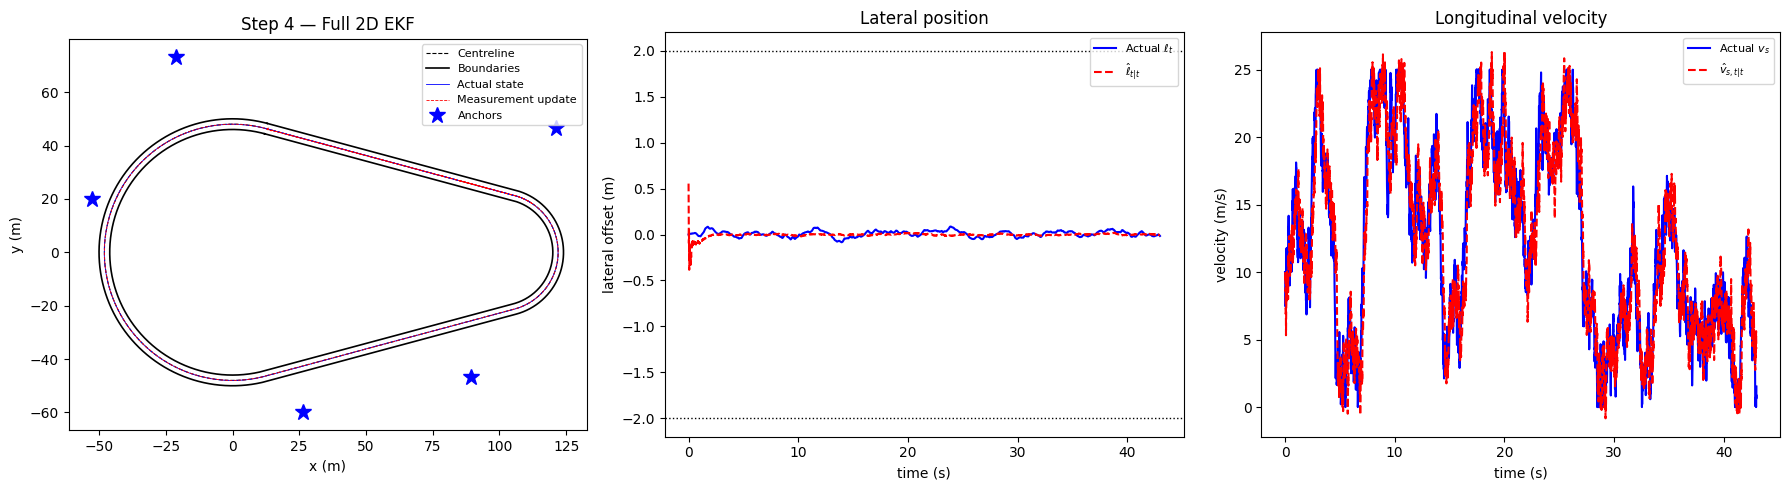

mean velocity error   : 2.024 m/s
max  velocity error   : 9.431 m/s
mean arc-length error : 0.244 m
mean lateral error    : 0.031 m
lateral bounds OK     : True
speed bounds OK       : True


In [1]:
!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

# ── Track geometry (A1, modelling.ipynb — ChenhuiCui) ─────────────────────
# Track geometry (A1, modelling.ipynb — ChenhuiCui, R_B corrected 20→22)
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A = (R_outer + r_inner) / 2    # centreline radius at A = 48.0 m
w   = (R_outer - r_inner) / 2    # track half-width = 2.0 m
R_B = rho + w                    # centreline radius at B = 22.0 m (rho is inner-wall radius)
alpha = np.arcsin((R_A - R_B) / d)
cos_a  = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan  = np.sqrt(d**2 - (R_A - R_B)**2)
L      = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1     = l_tan
s2     = s1 + R_B*(np.pi - 2*alpha)
s3     = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data ───────────────────────────────────────────────────────────
# State: z_t = [s, ell, vs, vl]  (A2, modelling.ipynb — ChenhuiCui)
# anchors: GDOP-optimised positions (A3, modelling.ipynb — ChenhuiCui)
dt = 0.01    # sampling time, 100 Hz (problem statement)

phi_vs = 0.999   # longitudinal AR(1) damping
phi_1  = 0.9     # lateral velocity damping
k2     = 10.0    # lateral restoring gain

# Beacon positions (A3, modelling.ipynb — GDOP greedy with R_B=22 corrected)
# 5 beacons: mean GDOP=0.9199, max GDOP=1.0036, ~100% track GDOP<1.0
anchors = np.array([
    [ -21.1,  73.3],
    [ 121.1,  46.7],
    [  26.3, -60.0],
    [ -52.6,  20.0],
    [  89.5, -46.7],
])
ny = len(anchors)
nx = 4

A = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])
Q = np.diag([0.5, 0.002])   # confirmed by A4 (0.003→0.002: bound-respecting model, partner's updated modelling.ipynb)
R    = 1.5**2 * np.eye(ny)
Qbar = G @ Q @ G.T

# ── System dynamics ────────────────────────────────────────────────────────
def f(x, w):
    x_plus     = A @ x
    x_plus[2] += 10.0 * (1 - phi_vs)   # nominal velocity drift (align EKF with true dynamics)
    x_plus[2] += w[0]
    x_plus[3] += w[1]
    x_plus[1]  = np.clip(x_plus[1], -2.0, 2.0)
    x_plus[2]  = np.clip(x_plus[2],  0.001, 25.0)
    return x_plus

# ── Create function h(z, v) using casadi ───────────────────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', ny)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

r_  = xy_c + ell_ * n_c
h_  = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + v_[i] for i in range(ny)])

# Determination of the Jacobian matrix of h
jhx = cs.jacobian(h_, z_)
jhv = cs.jacobian(h_, v_)
jhx = cs.Function('jhx', [z_, v_], [jhx])
jhv = cs.Function('jhv', [z_, v_], [jhv])

# Create a Function object for h
h = cs.Function('h', [z_, v_], [h_])

# ── EKF ────────────────────────────────────────────────────────────────────
def measurement_update(sigma_t_pred, x_t_pred, y_t):
    C    = jhx(x_t_pred, 0)
    Rv   = jhv(x_t_pred, 0)
    Z    = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update(sigma_t_meas, x_t_meas):
    x_t_pred     = f(x_t_meas, np.zeros(2))
    sigma_t_pred = A @ sigma_t_meas @ A.T + Qbar
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

# ── Simulation ─────────────────────────────────────────────────────────────
x_t          = np.array([0.0, 0.0, 10.0, 0.0])
x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300   # one full lap at ~10 m/s

x_cache          = np.zeros((N, nx))
x_meas_cache     = np.zeros((N-1, nx))
sigma_meas_cache = np.zeros((N-1, nx, nx))
x_cache[0, :]    = x_t.T

for t in range(N-1):
    # i. obtain measurement
    v_t = np.random.normal(0, 1.5, ny)
    y_t = h(x_t, v_t)

    # ii. measurement update
    sigma_t_meas, x_t_meas   = measurement_update(sigma_t_pred, x_t_pred, y_t)
    x_meas_cache[t, :]        = x_t_meas.T
    sigma_meas_cache[t, :, :] = sigma_t_meas

    # iii. Time update
    sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

    # iv. Dynamics
    w_t     = np.array([np.random.normal(0, np.sqrt(Q[0, 0])),
                        np.random.normal(0, np.sqrt(Q[1, 1]))])
    vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -w, w)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1, :] = x_t.T

# ── Plots ───────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s)      for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),     float(x_cache[t,1]))
                     for t in range(N)])
est_xy   = np.array([sl_to_xy(float(x_meas_cache[t,0]),float(x_meas_cache[t,1]))
                     for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.6, label='Measurement update')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=12,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title('Step 4 — Full 2D EKF')

t_ax = np.arange(N) * dt
axes[1].plot(t_ax,      x_cache[:,1],      'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', label=r'$\hat{\ell}_{t|t}$')
axes[1].axhline( w, color='k', ls=':', lw=1)
axes[1].axhline(-w, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b',   label=r'Actual $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', label=r'$\hat{v}_{s,t|t}$')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('time (s)');  axes[2].set_ylabel('velocity (m/s)')
axes[2].set_title('Longitudinal velocity')

plt.tight_layout()
plt.show()
print(f'mean velocity error   : {np.mean(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'max  velocity error   : {np.max(np.abs(x_cache[:-1,2]-x_meas_cache[:,2])):.3f} m/s')
print(f'mean arc-length error : {np.mean(np.abs(x_cache[:-1,0]-x_meas_cache[:,0])):.3f} m')
print(f'mean lateral error    : {np.mean(np.abs(x_cache[:-1,1]-x_meas_cache[:,1])):.3f} m')
print(f'lateral bounds OK     : {np.all(np.abs(x_cache[:,1]) <= w)}')
print(f'speed bounds OK       : {np.all((x_cache[:,2] > 0) & (x_cache[:,2] <= 25.0))}')